<a href="https://colab.research.google.com/github/faridashraf312-gif/bachelor-project/blob/main/Bachelor%20thesis%20by%20faridaashraf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Business Understanding

The objective of this project is to develop machine learning models to predict employee salary and bonus based on demographic, experience, and job-related features. This system aims to support HR decision-making in payroll planning, compensation analysis, and workforce management.

Data Inspection

Upload & Load Dataset

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
import pandas as pd

file_path = '/content/sample_data/bachelor dataset (1).xlsx'
sheet_name = 'WA_Fn-UseC_-HR-Employee-Attriti'
df = pd.read_excel(file_path, sheet_name=sheet_name)

print("Loaded successfully ✅")
display(df.head())

Loaded successfully ✅


,Age,DailyRate,Department,Gender,HourlyRate,JobRole,MonthlyIncome,MonthlyRate,PercentSalaryHike,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Unnamed: 14,Bonus,Annual Salary,Experience Ratio,Year
0,41,1102,Sales,Male,94,Sales Executive,5993,19479,11,8,6,4,0,5,NaN,659.23,71916,0.75,2020.0
1,49,279,Research & Development,Male,61,Research Scientist,5130,24907,23,10,10,7,1,7,NaN,1179.9,61560,1,2020.0
2,37,1373,Research & Development,Male,92,Laboratory Technician,2090,2396,15,7,0,0,0,0,NaN,313.5,25080,0,2020.0
3,33,1392,Research & Development,Female,56,Research Scientist,2909,23159,11,8,8,7,3,0,NaN,319.99,34908,1,2020.0
4,27,591,Research & Development,Male,40,Laboratory Technician,3468,16632,12,6,2,2,2,2,NaN,416.16,41616,0.333333,2020.0


In [7]:
from google.colab import files
import os

# Define the expected file path and sheet name
file_path = 'sample_data/bachelor dataset (1).xlsx'
sheet_name = 'WA_Fn-UseC_-HR-Employee-Attriti'

print(f"Please upload the expected file: '{os.path.basename(file_path)}'")
uploaded = files.upload()

if not uploaded:
    print("No file was uploaded.")
else:
    for uploaded_filename in uploaded.keys():
        print(f'User uploaded file "{uploaded_filename}"')

        target_dir = os.path.dirname(file_path)
        target_filename = os.path.basename(file_path)
        full_target_path = os.path.join(target_dir, target_filename)

        # Create the target directory if it doesn't exist
        if target_dir and not os.path.exists(target_dir):
            os.makedirs(target_dir)
            print(f"Created directory: {target_dir}")

        # Move the uploaded file to the specified target path
        try:
            # If the uploaded file is not the exact target_filename, it will be renamed.
            # If it's already the target_filename, it's just moved.
            if uploaded_filename != full_target_path: # Avoid moving if it's already in the target_path and has the correct name (unlikely for upload)
                os.rename(uploaded_filename, full_target_path)
                print(f"Moved '{uploaded_filename}' to '{full_target_path}'")
            else:
                print(f"File '{uploaded_filename}' already at target location.")
        except OSError as e:
            print(f"Error moving file: {e}. Checking if target file already exists.")
            if os.path.exists(full_target_path):
                print(f"File '{full_target_path}' already exists.")
            else:
                print(f"Could not move '{uploaded_filename}' to '{full_target_path}'. Please ensure the file is accessible and the path is valid.")
        break # Assuming only one file is expected to be uploaded for this specific path.

Please upload the expected file: 'bachelor dataset (1).xlsx'


Saving bachelor dataset (1).xlsx to bachelor dataset (1).xlsx
User uploaded file "bachelor dataset (1).xlsx"
Moved 'bachelor dataset (1).xlsx' to 'sample_data/bachelor dataset (1).xlsx'


Clean inspection-ready numeric conversion

In [9]:

# 3) CONVERT POSSIBLE NUMERIC COLUMNS


df_inspect = df.copy()

for col in df_inspect.columns:
    if df_inspect[col].dtype == 'object':
        cleaned_col = (
            df_inspect[col]
            .astype(str)
            .str.strip()
            .str.replace(',', '', regex=False)
            .str.replace('$', '', regex=False)
        )

        converted = pd.to_numeric(cleaned_col, errors='coerce')

        # Convert if at least 80% of non-null values are numeric after conversion
        non_null_original = df_inspect[col].notna().sum()
        non_null_converted = converted.notna().sum()

        if non_null_original > 0 and (non_null_converted / non_null_original) >= 0.80:
            df_inspect[col] = converted

print("✅ Numeric conversion completed for inspection")
display(df_inspect.head())

✅ Numeric conversion completed for inspection


,Age,DailyRate,Department,Gender,HourlyRate,JobRole,MonthlyIncome,MonthlyRate,PercentSalaryHike,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Unnamed: 14,Bonus,Annual Salary,Experience Ratio,Year
0,41.0,1102.0,Sales,Male,94.0,Sales Executive,5993.0,19479.0,11.0,8.0,6.0,4.0,0.0,5.0,NaN,659.23,71916.0,0.750000,2020.0
1,49.0,279.0,Research & Development,Male,61.0,Research Scientist,5130.0,24907.0,23.0,10.0,10.0,7.0,1.0,7.0,NaN,1179.90,61560.0,1.000000,2020.0
2,37.0,1373.0,Research & Development,Male,92.0,Laboratory Technician,2090.0,2396.0,15.0,7.0,0.0,0.0,0.0,0.0,NaN,313.50,25080.0,0.000000,2020.0
3,33.0,1392.0,Research & Development,Female,56.0,Research Scientist,2909.0,23159.0,11.0,8.0,8.0,7.0,3.0,0.0,NaN,319.99,34908.0,1.000000,2020.0
4,27.0,591.0,Research & Development,Male,40.0,Laboratory Technician,3468.0,16632.0,12.0,6.0,2.0,2.0,2.0,2.0,NaN,416.16,41616.0,0.333333,2020.0


In [10]:

# 4) MASTER DATA INSPECTION TABLE


inspection_table = pd.DataFrame({
    'Column': df_inspect.columns,
    'Data Type': df_inspect.dtypes.astype(str).values,
    'Non-Null Count': df_inspect.notnull().sum().values,
    'Null Count': df_inspect.isnull().sum().values,
    'Null %': ((df_inspect.isnull().sum() / len(df_inspect)) * 100).round(2).values,
    'Unique Values': df_inspect.nunique(dropna=True).values
})

display(inspection_table.sort_values(by=['Null %', 'Column'], ascending=[False, True]).reset_index(drop=True))

,Column,Data Type,Non-Null Count,Null Count,Null %,Unique Values
0,Unnamed: 14,float64,0,4414,100.00,0
1,Year,float64,1470,2944,66.70,1
2,Experience Ratio,float64,2918,1496,33.89,192
3,Age,float64,2940,1474,33.39,43
4,Annual Salary,float64,2940,1474,33.39,2687
5,Bonus,float64,2940,1474,33.39,2898
6,DailyRate,float64,2940,1474,33.39,886
7,HourlyRate,float64,2940,1474,33.39,71
8,MonthlyIncome,float64,2940,1474,33.39,2687
9,MonthlyRate,float64,2940,1474,33.39,1427


In [14]:

# 5) SHAPE / DUPLICATES / COLUMN

shape_table = pd.DataFrame({
    "Metric": ["Rows", "Columns", "Duplicate Rows", "Duplicate %"],
    "Value": [
        df_inspect.shape[0],
        df_inspect.shape[1],
        df_inspect.duplicated().sum(),
        round((df_inspect.duplicated().sum() / len(df_inspect)) * 100, 2)
    ]
})
print("🔹 Dataset shape and duplicates")
display(shape_table)

columns_table = pd.DataFrame({
    "Column Number": range(1, len(df_inspect.columns) + 1),
    "Column Name": df_inspect.columns
})
print("🔹 Column names")
display(columns_table)

🔹 Dataset shape and duplicates


,Metric,Value
0,Rows,4414.00
1,Columns,19.00
2,Duplicate Rows,1472.00
3,Duplicate %,33.35


🔹 Column names


,Column Number,Column Name
0,1,Age
1,2,DailyRate
2,3,Department
3,4,Gender
4,5,HourlyRate
5,6,JobRole
6,7,MonthlyIncome
7,8,MonthlyRate
8,9,PercentSalaryHike
9,10,TotalWorkingYears


Numerical summary table

In [11]:
import numpy as np

# 6) NUMERICAL SUMMARY TABLE

numeric_cols = df_inspect.select_dtypes(include=[np.number]).columns.tolist()

if len(numeric_cols) > 0:
    numeric_summary = df_inspect[numeric_cols].describe().T.reset_index()
    numeric_summary = numeric_summary.rename(columns={
        'index': 'Column',
        'count': 'Count',
        'mean': 'Mean',
        'std': 'Std',
        'min': 'Min',
        '25%': 'Q1',
        '50%': 'Median',
        '75%': 'Q3',
        'max': 'Max'
    })

    numeric_summary['Skewness'] = df_inspect[numeric_cols].skew().values.round(2)
    numeric_summary['Missing %'] = ((df_inspect[numeric_cols].isnull().sum() / len(df_inspect)) * 100).values.round(2)

    print("🔹 Summary statistics for numerical columns")
    display(numeric_summary)
else:
    print("No numerical columns found.")

🔹 Summary statistics for numerical columns


,Column,Count,Mean,Std,Min,Q1,Median,Q3,Max,Skewness,Missing %
0,Age,2940.0,36.923810,9.133819,18.00,30.000000,36.0,43.00000,60.000,0.41,33.39
1,DailyRate,2940.0,802.485714,403.440447,102.00,465.000000,802.0,1157.00000,1499.000,-0.00,33.39
2,HourlyRate,2940.0,65.891156,20.325969,30.00,48.000000,66.0,84.00000,100.000,-0.03,33.39
3,MonthlyIncome,2940.0,6828.077857,4958.789149,1009.00,3067.975000,5190.9,8723.00000,21998.900,1.38,33.39
4,MonthlyRate,2940.0,14313.103401,7116.575021,2094.00,8045.000000,14235.5,20462.00000,26999.000,0.02,33.39
5,PercentSalaryHike,2940.0,15.209524,3.659315,11.00,12.000000,14.0,18.00000,25.000,0.82,33.39
6,TotalWorkingYears,2940.0,11.279592,7.779458,0.00,6.000000,10.0,15.00000,40.000,1.12,33.39
7,YearsAtCompany,2940.0,7.008163,6.125483,0.00,3.000000,5.0,9.00000,40.000,1.76,33.39
8,YearsInCurrentRole,2940.0,4.229252,3.622521,0.00,2.000000,3.0,7.00000,18.000,0.92,33.39
9,YearsSinceLastPromotion,2940.0,2.187755,3.221882,0.00,0.000000,1.0,3.00000,15.000,1.98,33.39


Categorical summary table

In [12]:
# 7) CATEGORICAL SUMMARY TABLE

categorical_cols = df_inspect.select_dtypes(include=['object', 'category']).columns.tolist()

cat_rows = []
for col in categorical_cols:
    mode_series = df_inspect[col].mode(dropna=True)
    top_value = mode_series.iloc[0] if not mode_series.empty else np.nan

    value_counts = df_inspect[col].value_counts(dropna=True)
    top_freq = value_counts.iloc[0] if len(value_counts) > 0 else 0

    cat_rows.append({
        "Column": col,
        "Non-Null Count": df_inspect[col].notnull().sum(),
        "Null Count": df_inspect[col].isnull().sum(),
        "Null %": round((df_inspect[col].isnull().sum() / len(df_inspect)) * 100, 2),
        "Unique Values": df_inspect[col].nunique(dropna=True),
        "Top Value": top_value,
        "Top Frequency": top_freq
    })

categorical_summary = pd.DataFrame(cat_rows)

print("🔹 Summary statistics for categorical columns")
display(categorical_summary.sort_values(by='Null %', ascending=False).reset_index(drop=True))

🔹 Summary statistics for categorical columns


,Column,Non-Null Count,Null Count,Null %,Unique Values,Top Value,Top Frequency
0,Department,2941,1473,33.37,4,Research & Development,1922
1,Gender,2941,1473,33.37,3,Male,1766
2,JobRole,2941,1473,33.37,10,Sales Executive,652


Missing values table

In [13]:

# 9) MISSING VALUES TABLE


missing_table = pd.DataFrame({
    "Column": df_inspect.columns,
    "Missing Count": df_inspect.isnull().sum().values,
    "Missing %": ((df_inspect.isnull().sum() / len(df_inspect)) * 100).round(2).values
}).sort_values(by="Missing %", ascending=False).reset_index(drop=True)

print("🔹 Missing values table")
display(missing_table)

🔹 Missing values table


,Column,Missing Count,Missing %
0,Unnamed: 14,4414,100.00
1,Year,2944,66.70
2,Experience Ratio,1496,33.89
3,YearsWithCurrManager,1474,33.39
4,DailyRate,1474,33.39
5,Age,1474,33.39
6,HourlyRate,1474,33.39
7,TotalWorkingYears,1474,33.39
8,MonthlyIncome,1474,33.39
9,PercentSalaryHike,1474,33.39


Outlier summary table

In [14]:

# 10) OUTLIER SUMMARY TABLE USING IQR


outlier_rows = []

for col in numeric_cols:
    series = df_inspect[col].dropna()

    if len(series) > 0:
        Q1 = series.quantile(0.25)
        Q3 = series.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outlier_count = ((series < lower_bound) | (series > upper_bound)).sum()

        outlier_rows.append({
            "Column": col,
            "Q1": Q1,
            "Q3": Q3,
            "IQR": IQR,
            "Lower Bound": lower_bound,
            "Upper Bound": upper_bound,
            "Outlier Count": int(outlier_count),
            "Outlier %": round((outlier_count / len(series)) * 100, 2)
        })

outlier_table = pd.DataFrame(outlier_rows).sort_values(by='Outlier %', ascending=False).reset_index(drop=True)

print("🔹 Outlier summary table")
display(outlier_table)

🔹 Outlier summary table


,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,MonthlyIncome,3067.975000,8723.00000,5655.025000,-5414.562500,17205.537500,216,7.35
1,Annual Salary,36815.700000,104676.00000,67860.300000,-64974.750000,206466.450000,216,7.35
2,YearsSinceLastPromotion,0.000000,3.00000,3.000000,-4.500000,7.500000,214,7.28
3,YearsAtCompany,3.000000,9.00000,6.000000,-6.000000,18.000000,208,7.07
4,Bonus,478.438500,1299.49925,821.060750,-753.152625,2531.090375,192,6.53
5,TotalWorkingYears,6.000000,15.00000,9.000000,-7.500000,28.500000,126,4.29
6,YearsInCurrentRole,2.000000,7.00000,5.000000,-5.500000,14.500000,42,1.43
7,YearsWithCurrManager,2.000000,7.00000,5.000000,-5.500000,14.500000,28,0.95
8,PercentSalaryHike,12.000000,18.00000,6.000000,3.000000,27.000000,0,0.00
9,DailyRate,465.000000,1157.00000,692.000000,-573.000000,2195.000000,0,0.00


Target variable inspection: MonthlyIncome and Bonus

In [15]:

# 11) TARGET VARIABLE INSPECTION


target_vars = ['MonthlyIncome', 'Bonus']
existing_targets = [col for col in target_vars if col in df_inspect.columns]

target_rows = []

for target in existing_targets:
    series = pd.to_numeric(df_inspect[target], errors='coerce')

    target_rows.append({
        "Target": target,
        "Data Type": str(df_inspect[target].dtype),
        "Non-Null Count": series.notna().sum(),
        "Missing Count": series.isna().sum(),
        "Missing %": round((series.isna().sum() / len(series)) * 100, 2),
        "Unique Values": series.nunique(dropna=True),
        "Min": series.min(),
        "Q1": series.quantile(0.25),
        "Median": series.median(),
        "Mean": series.mean(),
        "Q3": series.quantile(0.75),
        "Max": series.max(),
        "Std": series.std(),
        "Skewness": series.skew()
    })

target_summary = pd.DataFrame(target_rows)

print("🔹 Target variables summary")
display(target_summary)

🔹 Target variables summary


,Target,Data Type,Non-Null Count,Missing Count,Missing %,Unique Values,Min,Q1,Median,Mean,Q3,Max,Std,Skewness
0,MonthlyIncome,float64,2940,1474,33.39,2687,1009.00,3067.9750,5190.9,6828.077857,8723.00000,21998.900,4958.789149,1.383527
1,Bonus,float64,2940,1474,33.39,2898,110.99,478.4385,758.6,1033.587950,1299.49925,5239.608,803.784639,1.741090


Target distributions and boxplots

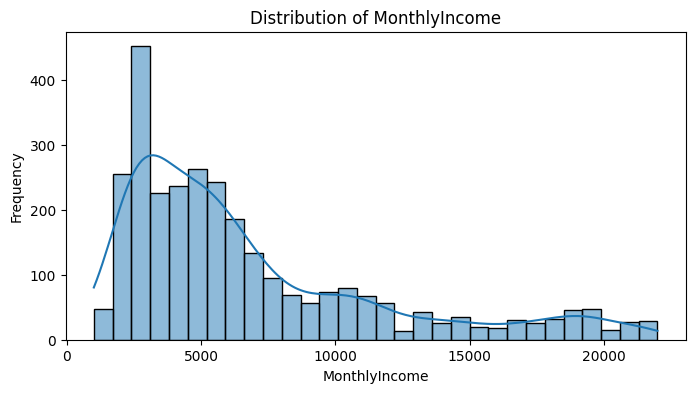

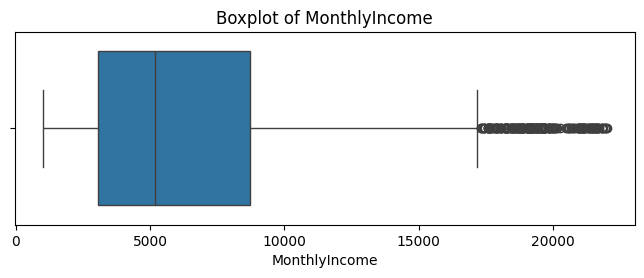

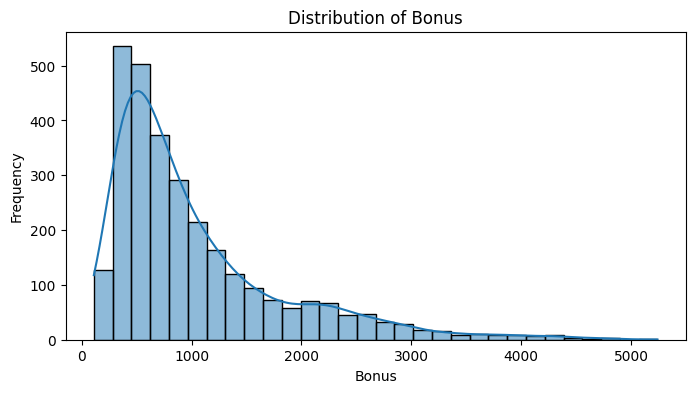

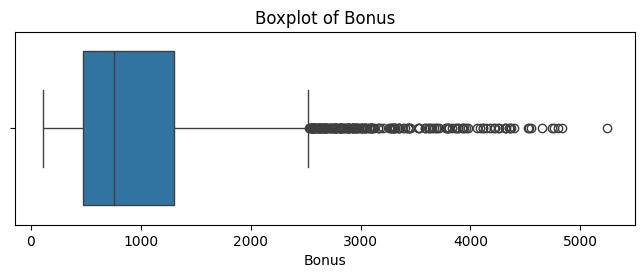

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# 12) TARGET DISTRIBUTIONS


for target in existing_targets:
    series = pd.to_numeric(df_inspect[target], errors='coerce').dropna()

    plt.figure(figsize=(8, 4))
    sns.histplot(series, bins=30, kde=True)
    plt.title(f"Distribution of {target}")
    plt.xlabel(target)
    plt.ylabel("Frequency")
    plt.show()

    plt.figure(figsize=(8, 2.5))
    sns.boxplot(x=series)
    plt.title(f"Boxplot of {target}")
    plt.show()

Correlation with targets

In [17]:

# 13) CORRELATION WITH TARGET VARIABLES


for target in existing_targets:
    temp_df = df_inspect.copy()
    temp_df[target] = pd.to_numeric(temp_df[target], errors='coerce')

    usable_numeric = temp_df.select_dtypes(include=[np.number]).columns.tolist()

    if target in usable_numeric:
        corr_table = (
            temp_df[usable_numeric]
            .corr()[target]
            .sort_values(ascending=False)
            .reset_index()
        )
        corr_table.columns = ['Feature', f'Correlation with {target}']

        print(f"🔹 Correlation with {target}")
        display(corr_table)

🔹 Correlation with MonthlyIncome


,Feature,Correlation with MonthlyIncome
0,Annual Salary,1.000000
1,MonthlyIncome,1.000000
2,Bonus,0.920686
3,TotalWorkingYears,0.770356
4,YearsAtCompany,0.512597
5,Age,0.496221
6,YearsInCurrentRole,0.362624
7,YearsSinceLastPromotion,0.343845
8,YearsWithCurrManager,0.342950
9,MonthlyRate,0.034699


🔹 Correlation with Bonus


,Feature,Correlation with Bonus
0,Bonus,1.000000
1,Annual Salary,0.920686
2,MonthlyIncome,0.920686
3,TotalWorkingYears,0.711949
4,YearsAtCompany,0.461947
5,Age,0.459607
6,YearsInCurrentRole,0.342648
7,YearsWithCurrManager,0.315218
8,YearsSinceLastPromotion,0.308370
9,PercentSalaryHike,0.290166


The correlation analysis shows that MonthlyIncome and Bonus are strongly influenced by Annual Salary and each other, with very high correlations from 0.92 to  1.00, making them key predictors but also potential sources of data leakage. Experience-related features such as TotalWorkingYears, YearsAtCompany, and Age are also strong indicators for both targets, showing moderate to high positive correlations (~0.46–0.77). In contrast, variables like MonthlyRate, DailyRate, and HourlyRate exhibit very weak or near-zero correlations, indicating little predictive value. Additionally, Experience Ratio shows a weak negative relationship, suggesting minimal inverse influence. Overall, compensation is mainly driven by salary-related and experience-based features, while rate-based variables contribute little to prediction.

Data Cleaning

In [18]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)

file_path = 'sample_data/bachelor dataset (1).xlsx'
sheet_name = 'WA_Fn-UseC_-HR-Employee-Attriti'

df = pd.read_excel(file_path, sheet_name=sheet_name)

# Remove empty rows
df = df.dropna(how='all').copy()

# Remove unnamed columns
df = df.loc[:, ~df.columns.astype(str).str.contains('^Unnamed')]

# Clean column names
df.columns = df.columns.astype(str).str.strip()

df = df.reset_index(drop=True)

print("Shape after structure fix:", df.shape)
display(df.head())

Shape after structure fix: (2941, 18)


,Age,DailyRate,Department,Gender,HourlyRate,JobRole,MonthlyIncome,MonthlyRate,PercentSalaryHike,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Bonus,Annual Salary,Experience Ratio,Year
0,41,1102,Sales,Male,94,Sales Executive,5993,19479,11,8,6,4,0,5,659.23,71916,0.75,2020.0
1,49,279,Research & Development,Male,61,Research Scientist,5130,24907,23,10,10,7,1,7,1179.9,61560,1,2020.0
2,37,1373,Research & Development,Male,92,Laboratory Technician,2090,2396,15,7,0,0,0,0,313.5,25080,0,2020.0
3,33,1392,Research & Development,Female,56,Research Scientist,2909,23159,11,8,8,7,3,0,319.99,34908,1,2020.0
4,27,591,Research & Development,Male,40,Laboratory Technician,3468,16632,12,6,2,2,2,2,416.16,41616,0.333333,2020.0


Convert numeric-like columns

In [19]:
# 3) CONVERT POSSIBLE NUMERIC COLUMNS

for col in df.columns:
    if df[col].dtype == 'object':
        cleaned_col = (
            df[col]
            .astype(str)
            .str.strip()
            .str.replace(',', '', regex=False)
            .str.replace('$', '', regex=False)
        )

        converted = pd.to_numeric(cleaned_col, errors='coerce')

        # Convert if at least 80% of non-null values are numeric after conversion
        non_null_original = df[col].notna().sum()
        non_null_converted = converted.notna().sum()

        if non_null_original > 0 and (non_null_converted / non_null_original) >= 0.80:
            df[col] = converted

print("✅ Numeric conversion completed for cleaning")
display(df.head())

✅ Numeric conversion completed for cleaning


,Age,DailyRate,Department,Gender,HourlyRate,JobRole,MonthlyIncome,MonthlyRate,PercentSalaryHike,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Bonus,Annual Salary,Experience Ratio,Year
0,41.0,1102.0,Sales,Male,94.0,Sales Executive,5993.0,19479.0,11.0,8.0,6.0,4.0,0.0,5.0,659.23,71916.0,0.750000,2020.0
1,49.0,279.0,Research & Development,Male,61.0,Research Scientist,5130.0,24907.0,23.0,10.0,10.0,7.0,1.0,7.0,1179.90,61560.0,1.000000,2020.0
2,37.0,1373.0,Research & Development,Male,92.0,Laboratory Technician,2090.0,2396.0,15.0,7.0,0.0,0.0,0.0,0.0,313.50,25080.0,0.000000,2020.0
3,33.0,1392.0,Research & Development,Female,56.0,Research Scientist,2909.0,23159.0,11.0,8.0,8.0,7.0,3.0,0.0,319.99,34908.0,1.000000,2020.0
4,27.0,591.0,Research & Development,Male,40.0,Laboratory Technician,3468.0,16632.0,12.0,6.0,2.0,2.0,2.0,2.0,416.16,41616.0,0.333333,2020.0


Handle missing values

In [20]:

# STEP 1: HANDLE HIDDEN MISSING VALUES

df.replace(["", " ", "NA", "N/A", "null", "None"], np.nan, inplace=True)


# STEP 2: HANDLE MISSING VALUES

# Separate types
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns

# Numerical → median
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical → most frequent
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


# STEP 3: AFTER TABLE ONLY

after_missing = pd.DataFrame({
    "Column": df.columns,
    "Missing Count": df.isnull().sum().values,
    "Missing %": (df.isnull().mean() * 100).round(2).values
})

# Sort to highlight any remaining issues
after_missing = after_missing.sort_values(by="Missing Count", ascending=False)

print("🔹 Missing Values After Handling")
display(after_missing)

🔹 Missing Values After Handling


,Column,Missing Count,Missing %
0,Age,0,0.0
1,DailyRate,0,0.0
2,Department,0,0.0
3,Gender,0,0.0
4,HourlyRate,0,0.0
5,JobRole,0,0.0
6,MonthlyIncome,0,0.0
7,MonthlyRate,0,0.0
8,PercentSalaryHike,0,0.0
9,TotalWorkingYears,0,0.0


Missing values were handled using appropriate imputation techniques. Numerical features were filled using median values to reduce the influence of outliers, while categorical features were imputed using the most frequent value. After this step, the dataset contained no missing values, ensuring completeness and consistency for model training.

Remove useless columns

In [21]:
# Drop columns with very low variance
low_variance = [col for col in df.columns if df[col].nunique() <= 1]

# Drop IDs if exist
id_cols = [col for col in df.columns if 'id' in col.lower()]

df = df.drop(columns=low_variance + id_cols, errors='ignore')

print("Dropped columns:", low_variance + id_cols)

Dropped columns: ['Year']


Feature Engineering

In [22]:

# FEATURE ENGINEERING


new_features = []

# Experience ratio
if 'TotalWorkingYears' in df.columns and 'Age' in df.columns:
    df['Experience_Ratio'] = df['TotalWorkingYears'] / df['Age']
    new_features.append('Experience_Ratio')

# Company loyalty
if 'YearsAtCompany' in df.columns and 'TotalWorkingYears' in df.columns:
    df['Company_Loyalty'] = df['YearsAtCompany'] / (df['TotalWorkingYears'] + 1)
    new_features.append('Company_Loyalty')
    df['Company_Loyalty'] = df['Company_Loyalty'].fillna(0)

# Career growth
if 'YearsInCurrentRole' in df.columns and 'YearsSinceLastPromotion' in df.columns:
    # Assuming Career_Growth is years in current role relative to years since last promotion
    df['Career_Growth'] = df['YearsInCurrentRole'] / (df['YearsSinceLastPromotion'] + 1)
    df['Career_Growth'] = df['Career_Growth'].clip(lower=0)
    new_features.append('Career_Growth')

# Income per experience
if 'MonthlyIncome' in df.columns and 'TotalWorkingYears' in df.columns:
    df['Income_per_Experience'] = df['MonthlyIncome'] / (df['TotalWorkingYears'] + 1)
    new_features.append('Income_per_Experience')
    # cap outliers
    Q1 = df['Income_per_Experience'].quantile(0.25)
    Q3 = df['Income_per_Experience'].quantile(0.75)
    IQR = Q3 - Q1

    upper = Q3 + 1.5 * IQR

    df['Income_per_Experience'] = df['Income_per_Experience'].clip(upper=upper)



# FEATURE ENGINEERING TABLE

if len(new_features) > 0:
    feature_table = pd.DataFrame({
        "Feature": new_features,
        "Data Type": [df[col].dtype for col in new_features],
        "Mean": [df[col].mean() for col in new_features],
        "Std": [df[col].std() for col in new_features],
        "Min": [df[col].min() for col in new_features],
        "Max": [df[col].max() for col in new_features],
        "Missing %": [(df[col].isnull().mean() * 100) for col in new_features],
        "Unique Values": [df[col].nunique() for col in new_features]
    })

    print("🔹 Feature Engineering Results Table")
    display(feature_table)
else:
    print("No new features were created.")
    for target in ['MonthlyIncome', 'Bonus']:
        if target in df.columns:
            print(f"\n🔹 Correlation of new features with {target}")
            corr = df[new_features + [target]].corr()[target].sort_values(ascending=False)
            display(corr.to_frame(name=f"Correlation with {target}"))


🔹 Feature Engineering Results Table


,Feature,Data Type,Mean,Std,Min,Max,Missing %,Unique Values
0,Experience_Ratio,float64,0.288004,0.153377,0.000000,0.689655,0.0,409
1,Company_Loyalty,float64,0.581787,0.284389,0.000000,0.975610,0.0,211
2,Career_Growth,float64,1.872416,2.022307,0.000000,16.000000,0.0,103
3,Income_per_Experience,float64,611.269844,283.313884,95.285714,1349.400000,0.0,2799


Feature engineering was performed to enhance the predictive capability of the models. New variables such as Experience Ratio, Company Loyalty, and Career Growth were created to capture meaningful relationships between existing features. These engineered features provide additional insights into employee experience and progression, which are expected to influence salary and bonus predictions.

Handle outliers

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# OUTLIER CAPPING FUNCTION

def cap_outliers_with_report(df, columns):
    df_before = df.copy()
    df_after = df.copy()
    report_rows = []

    for col in columns:
        series_before = df_before[col].dropna()

        Q1 = series_before.quantile(0.25)
        Q3 = series_before.quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers_before_mask = (df_before[col] < lower) | (df_before[col] > upper)
        outliers_before_count = outliers_before_mask.sum()
        outliers_before_pct = round((outliers_before_count / df_before[col].notna().sum()) * 100, 2)

        df_after[col] = df_after[col].clip(lower, upper)

        outliers_after_mask = (df_after[col] < lower) | (df_after[col] > upper)
        outliers_after_count = outliers_after_mask.sum()
        outliers_after_pct = round((outliers_after_count / df_after[col].notna().sum()) * 100, 2)

        report_rows.append({
            "Column": col,
            "Q1": round(Q1, 2),
            "Q3": round(Q3, 2),
            "IQR": round(IQR, 2),
            "Lower Bound": round(lower, 2),
            "Upper Bound": round(upper, 2),
            "Outliers Before": int(outliers_before_count),
            "Outliers Before %": outliers_before_pct,
            "Outliers After": int(outliers_after_count),
            "Outliers After %": outliers_after_pct,
            "Capped Values": int(outliers_before_count - outliers_after_count)
        })

    report_df = pd.DataFrame(report_rows).sort_values(by="Outliers Before", ascending=False).reset_index(drop=True)
    return df_after, report_df, df_before



# SELECT COLUMNS TO CAP
# Do NOT cap targets aggressively
target_cols = ['MonthlyIncome', 'Bonus', 'Annual Salary']

num_cols = df.select_dtypes(include=np.number).columns
cols_to_cap = [col for col in num_cols if col not in target_cols]

# Apply capping + get report
df, outlier_report, df_before_outliers = cap_outliers_with_report(df, cols_to_cap)

print("🔹 Outlier Handling Summary Table")
display(outlier_report)

🔹 Outlier Handling Summary Table


,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers Before,Outliers Before %,Outliers After,Outliers After %,Capped Values
0,Career_Growth,0.67,2.25,1.58,-1.71,4.62,256,8.70,0,0.0,256
1,YearsSinceLastPromotion,0.00,3.00,3.00,-4.50,7.50,214,7.28,0,0.0,214
2,YearsAtCompany,3.00,9.00,6.00,-6.00,18.00,208,7.07,0,0.0,208
3,TotalWorkingYears,6.00,15.00,9.00,-7.50,28.50,126,4.28,0,0.0,126
4,YearsInCurrentRole,2.00,7.00,5.00,-5.50,14.50,42,1.43,0,0.0,42
5,YearsWithCurrManager,2.00,7.00,5.00,-5.50,14.50,28,0.95,0,0.0,28
6,Age,30.00,43.00,13.00,10.50,62.50,0,0.00,0,0.0,0
7,MonthlyRate,8045.00,20462.00,12417.00,-10580.50,39087.50,0,0.00,0,0.0,0
8,PercentSalaryHike,12.00,18.00,6.00,3.00,27.00,0,0.00,0,0.0,0
9,DailyRate,465.00,1157.00,692.00,-573.00,2195.00,0,0.00,0,0.0,0


Outliers in numerical features were identified and handled using the Interquartile Range (IQR) method. Extreme values were capped within acceptable bounds to minimize their impact on model performance while preserving the overall data distribution. This step improved data robustness and reduced the risk of model bias caused by extreme observations.

Fix skewed targets

In [24]:
# Log transform for skewed targets
if 'MonthlyIncome' in df.columns:
    df['MonthlyIncome_log'] = np.log1p(df['MonthlyIncome'])

if 'Bonus' in df.columns:
    df['Bonus_log'] = np.log1p(df['Bonus'])

Logarithmic transformation was applied to the target variables (Monthly Income and Bonus) to address skewness and stabilize variance. This transformation resulted in a more normalized distribution, which improves the performance and reliability of machine learning models.

Encode categorical variables

In [25]:

# STEP 1: Identify categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()

print("Categorical columns to encode:", cat_cols)

# STEP 2: Apply encoding ONLY on them
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print("Encoded dataset shape:", df_encoded.shape)
# Remove wrong duplicated dummy columns
bad_cols = [col for col in df_encoded.columns if 'Gender_Gender' in col or 'JobRole_JobRole' in col]

df_encoded = df_encoded.drop(columns=bad_cols, errors='ignore')
display(pd.DataFrame({
    "Column": df_encoded.columns,
    "Unique Values": df_encoded.nunique()
}))
# Drop leakage + duplicate columns
df = df.drop(columns=[
    'Annual Salary',
    'MonthlyIncome',
    'Bonus',
    'Experience Ratio'
], errors='ignore')

print("Final columns:", df.columns)
print("Final shape:", df.shape)

Categorical columns to encode: ['Department', 'Gender', 'JobRole']
Encoded dataset shape: (2941, 34)


,Column,Unique Values
Age,Age,43
DailyRate,DailyRate,886
HourlyRate,HourlyRate,71
MonthlyIncome,MonthlyIncome,2688
MonthlyRate,MonthlyRate,1428
PercentSalaryHike,PercentSalaryHike,15
TotalWorkingYears,TotalWorkingYears,30
YearsAtCompany,YearsAtCompany,19
YearsInCurrentRole,YearsInCurrentRole,16
YearsSinceLastPromotion,YearsSinceLastPromotion,9


Final columns: Index(['Age', 'DailyRate', 'Department', 'Gender', 'HourlyRate', 'JobRole',
       'MonthlyRate', 'PercentSalaryHike', 'TotalWorkingYears',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'Experience_Ratio', 'Company_Loyalty',
       'Career_Growth', 'Income_per_Experience', 'MonthlyIncome_log',
       'Bonus_log'],
      dtype='object')
Final shape: (2941, 19)


Categorical variables were converted into numerical format using one-hot encoding. This transformation allows machine learning algorithms to effectively process categorical information by representing each category as a binary feature. The encoding process increased the dimensionality of the dataset but ensured that no information was lost.

Final cleaning check table

In [26]:
final_summary = pd.DataFrame({
    "Column": df_encoded.columns,
    "Data Type": df_encoded.dtypes,
    "Null %": (df_encoded.isnull().mean() * 100).round(2),
    "Unique Values": df_encoded.nunique()
})

display(final_summary)

,Column,Data Type,Null %,Unique Values
Age,Age,float64,0.0,43
DailyRate,DailyRate,float64,0.0,886
HourlyRate,HourlyRate,float64,0.0,71
MonthlyIncome,MonthlyIncome,float64,0.0,2688
MonthlyRate,MonthlyRate,float64,0.0,1428
PercentSalaryHike,PercentSalaryHike,float64,0.0,15
TotalWorkingYears,TotalWorkingYears,float64,0.0,30
YearsAtCompany,YearsAtCompany,float64,0.0,19
YearsInCurrentRole,YearsInCurrentRole,float64,0.0,16
YearsSinceLastPromotion,YearsSinceLastPromotion,float64,0.0,9


show only columns that has outliers

In [27]:
display(outlier_report[outlier_report["Outliers Before"] > 0])

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers Before,Outliers Before %,Outliers After,Outliers After %,Capped Values
0,Career_Growth,0.67,2.25,1.58,-1.71,4.62,256,8.70,0,0.0,256
1,YearsSinceLastPromotion,0.00,3.00,3.00,-4.50,7.50,214,7.28,0,0.0,214
2,YearsAtCompany,3.00,9.00,6.00,-6.00,18.00,208,7.07,0,0.0,208
3,TotalWorkingYears,6.00,15.00,9.00,-7.50,28.50,126,4.28,0,0.0,126
4,YearsInCurrentRole,2.00,7.00,5.00,-5.50,14.50,42,1.43,0,0.0,42
5,YearsWithCurrManager,2.00,7.00,5.00,-5.50,14.50,28,0.95,0,0.0,28


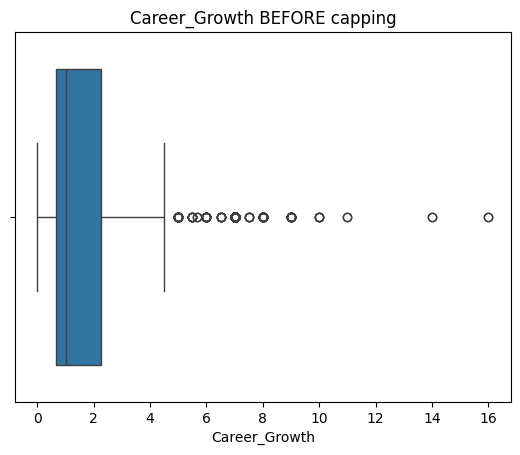

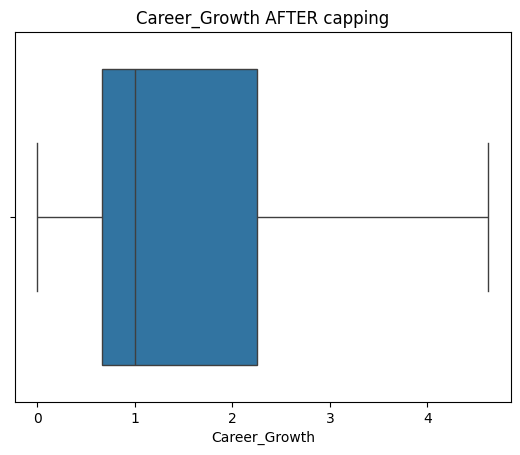

In [28]:
sns.boxplot(x=df_before_outliers["Career_Growth"])
plt.title("Career_Growth BEFORE capping")
plt.show()

sns.boxplot(x=df["Career_Growth"])
plt.title("Career_Growth AFTER capping")
plt.show()

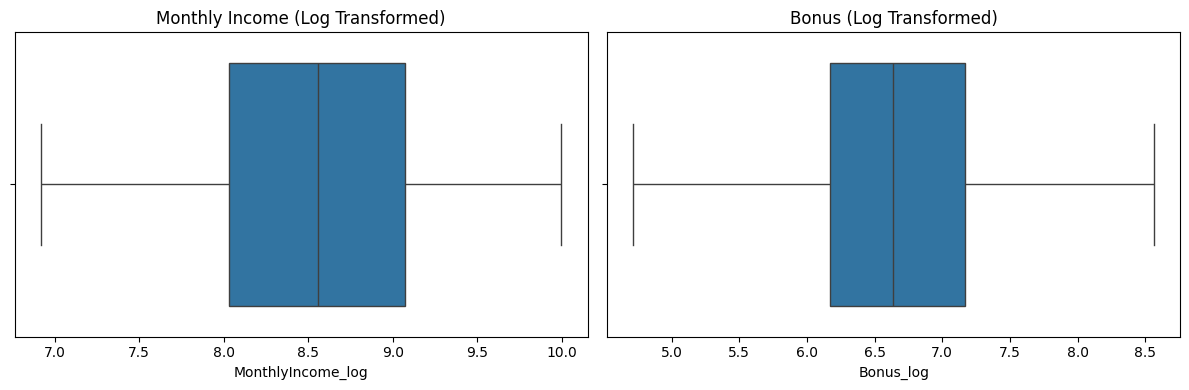

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x=df['MonthlyIncome_log'], ax=axes[0])
axes[0].set_title("Monthly Income (Log Transformed)")

sns.boxplot(x=df['Bonus_log'], ax=axes[1])
axes[1].set_title("Bonus (Log Transformed)")

plt.tight_layout()
plt.show()

compare BEFORE vs AFTER

Outlier Comparison Table


,Column,Outliers Before,Outliers After,Reduction
0,MonthlyIncome,216,0,216
1,Bonus,192,0,192


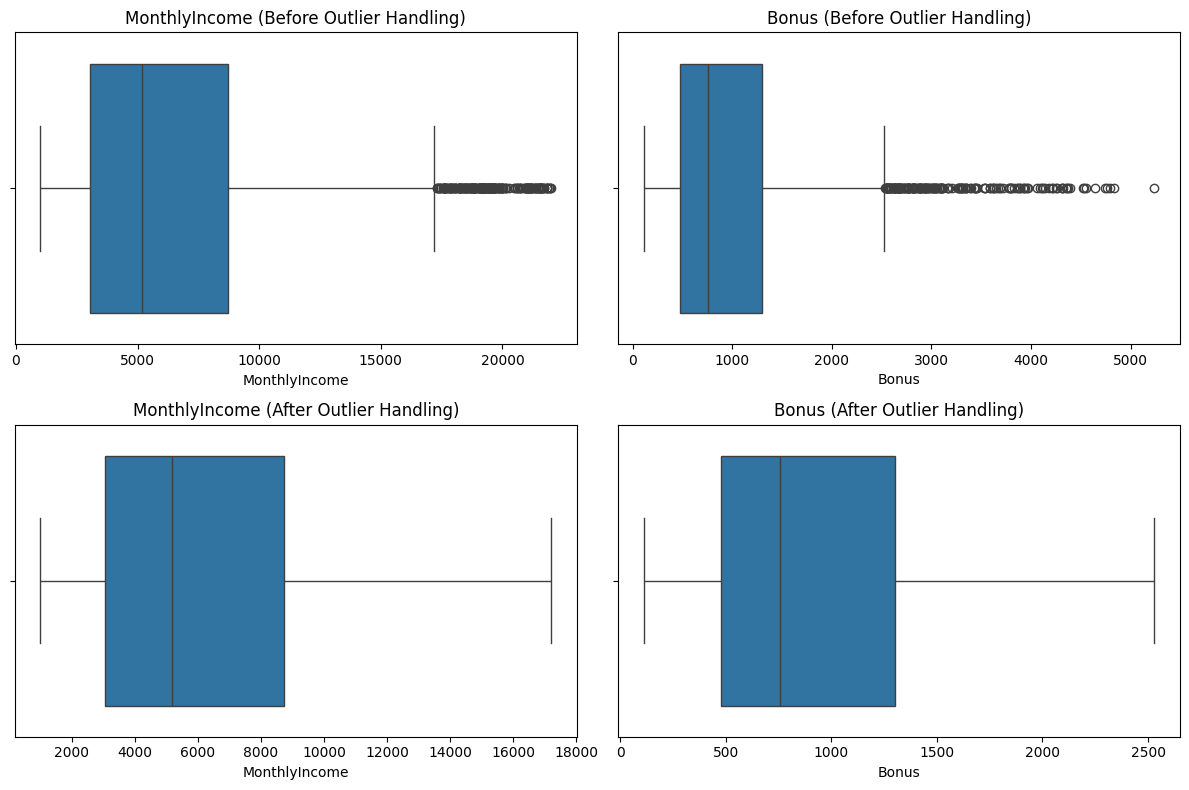

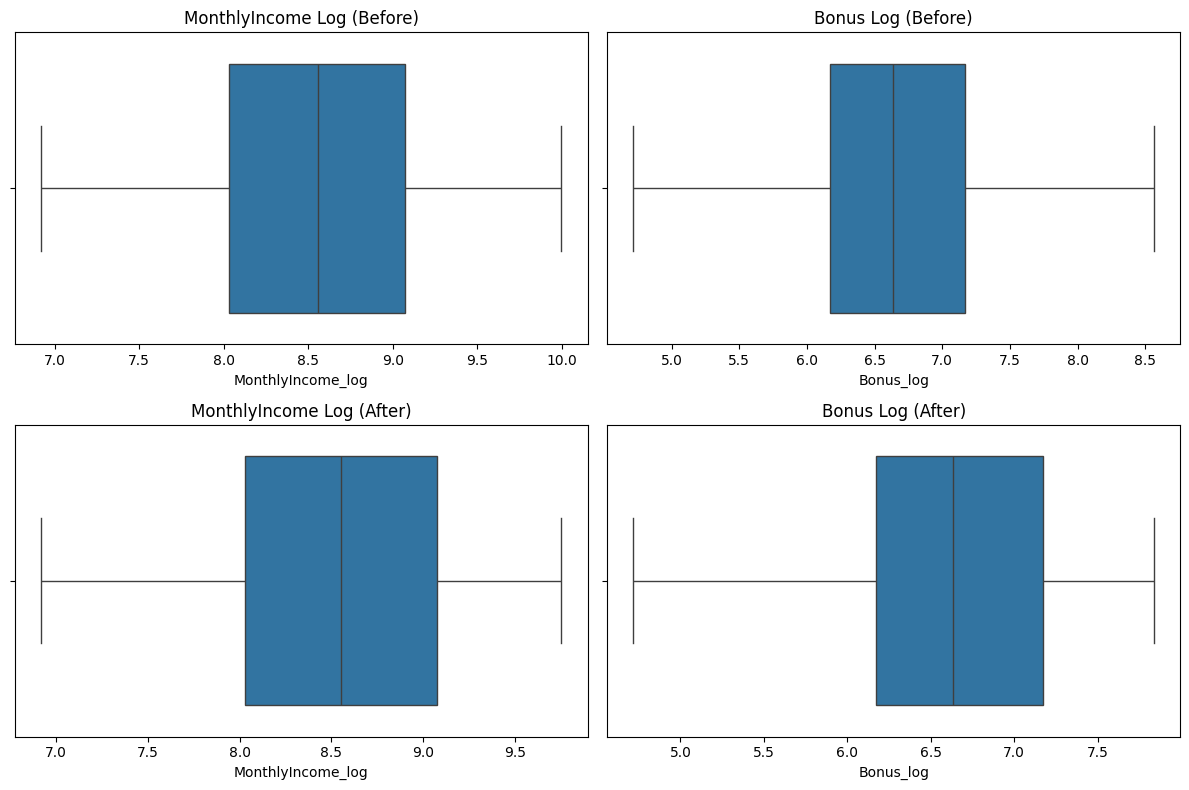

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. LOAD AND BASIC CLEANING
file_path = 'sample_data/bachelor dataset (1).xlsx'
sheet_name = 'WA_Fn-UseC_-HR-Employee-Attriti'

df = pd.read_excel(file_path, sheet_name=sheet_name)

# Remove empty rows
df = df.dropna(how='all').copy()

# Remove unnamed columns
df = df.loc[:, ~df.columns.astype(str).str.contains('^Unnamed', case=False)]

# Clean column names
df.columns = df.columns.astype(str).str.strip()

# Replace hidden missing values
df.replace(["", " ", "NA", "N/A", "null", "None"], np.nan, inplace=True)

# 2. CONVERT NUMERIC-LIKE COLUMNS
for col in df.columns:
    if df[col].dtype == 'object':
        cleaned = (
            df[col]
            .astype(str)
            .str.strip()
            .str.replace(',', '', regex=False)
            .str.replace('$', '', regex=False)
        )
        converted = pd.to_numeric(cleaned, errors='coerce')

        non_null_original = df[col].notna().sum()
        non_null_converted = converted.notna().sum()

        if non_null_original > 0 and (non_null_converted / non_null_original) >= 0.80:
            df[col] = converted

# 3. HANDLE MISSING VALUES
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# 4. SAVE TRUE "BEFORE OUTLIERS" COPY
df_before_outliers = df.copy()

# 5. OUTLIER CAPPING FUNCTION
def cap_outliers(df_in, columns):
    df_out = df_in.copy()

    for col in columns:
        Q1 = df_out[col].quantile(0.25)
        Q3 = df_out[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df_out[col] = df_out[col].clip(lower=lower, upper=upper)

    return df_out
# 6. APPLY OUTLIER HANDLING
cols_to_cap = ['MonthlyIncome', 'Bonus']

existing_cols_to_cap = [col for col in cols_to_cap if col in df.columns]

df_after_outliers = cap_outliers(df, existing_cols_to_cap)

# 7. CREATE LOG COLUMNS FOR BOTH BEFORE AND AFTER
if 'MonthlyIncome' in df_before_outliers.columns:
    df_before_outliers['MonthlyIncome_log'] = np.log1p(df_before_outliers['MonthlyIncome'])

if 'Bonus' in df_before_outliers.columns:
    df_before_outliers['Bonus_log'] = np.log1p(df_before_outliers['Bonus'])

if 'MonthlyIncome' in df_after_outliers.columns:
    df_after_outliers['MonthlyIncome_log'] = np.log1p(df_after_outliers['MonthlyIncome'])

if 'Bonus' in df_after_outliers.columns:
    df_after_outliers['Bonus_log'] = np.log1p(df_after_outliers['Bonus'])

# 8. OUTLIER SUMMARY TABLE
report_rows = []

for col in existing_cols_to_cap:
    # Before
    Q1_before = df_before_outliers[col].quantile(0.25)
    Q3_before = df_before_outliers[col].quantile(0.75)
    IQR_before = Q3_before - Q1_before
    lower_before = Q1_before - 1.5 * IQR_before
    upper_before = Q3_before + 1.5 * IQR_before
    outliers_before = ((df_before_outliers[col] < lower_before) | (df_before_outliers[col] > upper_before)).sum()

    # After
    Q1_after = df_after_outliers[col].quantile(0.25)
    Q3_after = df_after_outliers[col].quantile(0.75)
    IQR_after = Q3_after - Q1_after
    lower_after = Q1_after - 1.5 * IQR_after
    upper_after = Q3_after + 1.5 * IQR_after
    outliers_after = ((df_after_outliers[col] < lower_after) | (df_after_outliers[col] > upper_after)).sum()

    report_rows.append({
        "Column": col,
        "Outliers Before": int(outliers_before),
        "Outliers After": int(outliers_after),
        "Reduction": int(outliers_before - outliers_after)
    })

outlier_compare_table = pd.DataFrame(report_rows)
print("Outlier Comparison Table")
display(outlier_compare_table)

# 9. TRUE BEFORE VS AFTER BOXPLOTS
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# BEFORE
sns.boxplot(x=df_before_outliers['MonthlyIncome'], ax=axes[0, 0])
axes[0, 0].set_title("MonthlyIncome (Before Outlier Handling)")

sns.boxplot(x=df_before_outliers['Bonus'], ax=axes[0, 1])
axes[0, 1].set_title("Bonus (Before Outlier Handling)")

# AFTER
sns.boxplot(x=df_after_outliers['MonthlyIncome'], ax=axes[1, 0])
axes[1, 0].set_title("MonthlyIncome (After Outlier Handling)")

sns.boxplot(x=df_after_outliers['Bonus'], ax=axes[1, 1])
axes[1, 1].set_title("Bonus (After Outlier Handling)")

plt.tight_layout()
plt.show()


# 10. TRUE BEFORE VS AFTER LOG BOXPLOTS
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# BEFORE LOG
sns.boxplot(x=df_before_outliers['MonthlyIncome_log'], ax=axes[0, 0])
axes[0, 0].set_title("MonthlyIncome Log (Before)")

sns.boxplot(x=df_before_outliers['Bonus_log'], ax=axes[0, 1])
axes[0, 1].set_title("Bonus Log (Before)")

# AFTER LOG
sns.boxplot(x=df_after_outliers['MonthlyIncome_log'], ax=axes[1, 0])
axes[1, 0].set_title("MonthlyIncome Log (After)")

sns.boxplot(x=df_after_outliers['Bonus_log'], ax=axes[1, 1])
axes[1, 1].set_title("Bonus Log (After)")

plt.tight_layout()
plt.show()

In [31]:
df = df.drop(columns=['Experience Ratio'], errors='ignore')

In [32]:
# Drop leakage + duplicate columns
df = df.drop(columns=[
    'Annual Salary',
    'MonthlyIncome',
    'Bonus',
    'Experience Ratio'
], errors='ignore')

print("Final columns:", df.columns)
print("Final shape:", df.shape)

Final columns: Index(['Age', 'DailyRate', 'Department', 'Gender', 'HourlyRate', 'JobRole',
       'MonthlyRate', 'PercentSalaryHike', 'TotalWorkingYears',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'Year'],
      dtype='object')
Final shape: (2941, 14)


In [33]:
bad_cols = [col for col in df.columns if "_JobRole" in col or "_Gender" in col]

print("Check these columns:")
print(bad_cols)

Check these columns:
[]


In [34]:
duplicate_cols = df.columns[df.columns.duplicated()]
print("Duplicate columns:", duplicate_cols)
df = df.loc[:, ~df.columns.duplicated()]

Duplicate columns: Index([], dtype='object')


In [35]:
unique_table = pd.DataFrame({
    "Column": df.columns,
    "Unique Values": df.nunique(),
    "Unique %": (df.nunique() / len(df)) * 100
}).sort_values(by="Unique %", ascending=False)

display(unique_table)

,Column,Unique Values,Unique %
MonthlyRate,MonthlyRate,1428,48.554913
DailyRate,DailyRate,886,30.125808
HourlyRate,HourlyRate,71,2.414145
Age,Age,43,1.462088
TotalWorkingYears,TotalWorkingYears,40,1.360082
YearsAtCompany,YearsAtCompany,37,1.258075
YearsInCurrentRole,YearsInCurrentRole,19,0.646039
YearsWithCurrManager,YearsWithCurrManager,18,0.612037
YearsSinceLastPromotion,YearsSinceLastPromotion,16,0.544033
PercentSalaryHike,PercentSalaryHike,15,0.510031


Remove leakage columns

In [36]:
# Columns to drop for salary prediction
drop_salary = ['MonthlyIncome', 'Annual Salary', 'Bonus']

# Columns to drop for bonus prediction
drop_bonus = ['Bonus', 'MonthlyIncome', 'Annual Salary']

In [37]:
df_encoded.to_csv("cleaned_payroll_dataset.csv", index=False)
print("✅ Clean dataset saved")

✅ Clean dataset saved


Building the model

1-Salary Model

Define X and y

In [38]:
# REMOVE LEAKAGE FEATURE
if 'Income_per_Experience' in df.columns:
    print("⚠️ Removing leakage feature: Income_per_Experience")
    df = df.drop(columns=['Income_per_Experience'])

In [39]:

# FINAL SALARY DATASET

df_model = df_encoded.copy()

# Remove leakage feature
df_model = df_model.drop(columns=['Income_per_Experience'], errors='ignore')

# Remove ALL leakage columns
X_salary = df_model.drop(
    columns=[
        'MonthlyIncome_log',
        'Bonus_log',
        'MonthlyIncome',
        'Bonus',
        'Annual Salary'
    ],
    errors='ignore'
)

y_salary = df_model['MonthlyIncome_log']

Split the data

In [40]:
from sklearn.model_selection import train_test_split

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_salary, y_salary, test_size=0.2, random_state=42
)

Build baseline models

In [41]:
print("X_salary columns:")
print(X_salary.columns.tolist())

print("\nLeakage checks:")
for col in ['MonthlyIncome', 'Bonus', 'Annual Salary', 'Income_per_Experience', 'MonthlyIncome_log', 'Bonus_log']:
    print(col, "->", col in X_salary.columns)

X_salary columns:
['Age', 'DailyRate', 'HourlyRate', 'MonthlyRate', 'PercentSalaryHike', 'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Experience Ratio', 'Experience_Ratio', 'Company_Loyalty', 'Career_Growth', 'Department_Human Resources', 'Department_Research & Development', 'Department_Sales', 'Gender_Male', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Director', 'JobRole_Research Director', 'JobRole_Research Scientist', 'JobRole_Sales Executive', 'JobRole_Sales Representative']

Leakage checks:
MonthlyIncome -> False
Bonus -> False
Annual Salary -> False
Income_per_Experience -> False
MonthlyIncome_log -> False
Bonus_log -> False


In [42]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

models = {
    "RandomForest": RandomForestRegressor(random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train_s, y_train_s)
    preds = model.predict(X_test_s)

    results.append({
        "Model": name,
        "R2": r2_score(y_test_s, preds),
        "MAE": mean_absolute_error(y_test_s, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test_s, preds))
    })

import pandas as pd
results_df = pd.DataFrame(results)
display(results_df)

,Model,R2,MAE,RMSE
0,RandomForest,0.938953,0.121641,0.162992
1,GradientBoosting,0.853666,0.201158,0.252351


Hyperparameter tuning

In [43]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

param_dist = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=5,          # smaller
    cv=3,              # faster than 5
    scoring="r2",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search.fit(X_train_s, y_train_s)

best_model = search.best_estimator_

preds = best_model.predict(X_test_s)

print("Best Parameters:", search.best_params_)
print("R2:", r2_score(y_test_s, preds))
print("MAE:", mean_absolute_error(y_test_s, preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test_s, preds)))

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
R2: 0.938953142076721
MAE: 0.12164078525734262
RMSE: 0.16299154850353345


Evaluate best model

In [44]:
preds = best_model.predict(X_test_s)

r2 = r2_score(y_test_s, preds)
mae = mean_absolute_error(y_test_s, preds)
rmse = np.sqrt(mean_squared_error(y_test_s, preds))

print("R2:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

R2: 0.9389531420767211
MAE: 0.12164078525734257
RMSE: 0.16299154850353342


In [45]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=42)

gb.fit(X_train_s, y_train_s)
gb_preds = gb.predict(X_test_s)

print("Gradient Boosting Results:")
print("R2:", r2_score(y_test_s, gb_preds))
print("MAE:", mean_absolute_error(y_test_s, gb_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test_s, gb_preds)))

Gradient Boosting Results:
R2: 0.8536662299827504
MAE: 0.20115810860100355
RMSE: 0.25235139431588594


The Random Forest model outperformed Gradient Boosting across all evaluation metrics, achieving higher R² and lower error values. Therefore, Random Forest was selected as the final model for salary prediction due to its superior accuracy and stability.



2- Bonus model

Define features and target

In [46]:
# Make sure log targets exist
if 'MonthlyIncome' in df.columns and 'MonthlyIncome_log' not in df.columns:
    df['MonthlyIncome_log'] = np.log1p(df['MonthlyIncome'])

if 'Bonus' in df.columns and 'Bonus_log' not in df.columns:
    df['Bonus_log'] = np.log1p(df['Bonus'])

print(df.columns.tolist())

['Age', 'DailyRate', 'Department', 'Gender', 'HourlyRate', 'JobRole', 'MonthlyRate', 'PercentSalaryHike', 'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Year']


In [47]:
# Freeze final modeling dataframe
df_model = df_encoded.copy()

# Make sure log targets are present in df_model
if 'MonthlyIncome' in df_model.columns and 'MonthlyIncome_log' not in df_model.columns:
    df_model['MonthlyIncome_log'] = np.log1p(df_model['MonthlyIncome'])

if 'Bonus' in df_model.columns and 'Bonus_log' not in df_model.columns:
    df_model['Bonus_log'] = np.log1p(df_model['Bonus'])

print("MonthlyIncome_log in df_model ->", 'MonthlyIncome_log' in df_model.columns)
print("Bonus_log in df_model ->", 'Bonus_log' in df_model.columns)

MonthlyIncome_log in df_model -> True
Bonus_log in df_model -> True


In [48]:

# BONUS MODEL

# final modeling dataframe
df_model = df_encoded.copy()

# ensure targets exist
if 'MonthlyIncome' in df_model.columns and 'MonthlyIncome_log' not in df_model.columns:
    df_model['MonthlyIncome_log'] = np.log1p(df_model['MonthlyIncome'])

if 'Bonus' in df_model.columns and 'Bonus_log' not in df_model.columns:
    df_model['Bonus_log'] = np.log1p(df_model['Bonus'])

# remove leakage columns if they exist
bonus_leakage_cols = [
    'Bonus',
    'Annual Salary',
    'Income_per_Experience',
    'MonthlyIncome'
]

# target
y_bonus = df_model['Bonus_log']

# features
X_bonus = df_model.drop(
    columns=[
        'Bonus_log',
        'MonthlyIncome_log',
        'Bonus',
        'Annual Salary',
        'Income_per_Experience',
        'MonthlyIncome'
    ],
    errors='ignore'
)

print("Leakage checks:")
for col in ['Bonus', 'Annual Salary', 'Income_per_Experience', 'MonthlyIncome', 'Bonus_log', 'MonthlyIncome_log']:
    print(col, "->", col in X_bonus.columns)

print("\nTarget exists:", 'Bonus_log' in df_model.columns)
print("X_bonus shape:", X_bonus.shape)
print("y_bonus shape:", y_bonus.shape)

Leakage checks:
Bonus -> False
Annual Salary -> False
Income_per_Experience -> False
MonthlyIncome -> False
Bonus_log -> False
MonthlyIncome_log -> False

Target exists: True
X_bonus shape: (2941, 26)
y_bonus shape: (2941,)


Remove leakage features

In [49]:
# Remove leakage / overly direct compensation columns
leakage_bonus_cols = [
    'Bonus',                 # original target
    'Annual Salary',         # direct compensation summary
    'Income_per_Experience'  # derived from MonthlyIncome
]

existing_leakage_bonus = [col for col in leakage_bonus_cols if col in X_bonus.columns]

if existing_leakage_bonus:
    print("Removing leakage-related columns:", existing_leakage_bonus)
    X_bonus = X_bonus.drop(columns=existing_leakage_bonus, errors='ignore')

Quick check of final features

In [50]:
print("X_bonus shape:", X_bonus.shape)
print("y_bonus shape:", y_bonus.shape)
print("Remaining columns:")
print(X_bonus.columns.tolist())

X_bonus shape: (2941, 26)
y_bonus shape: (2941,)
Remaining columns:
['Age', 'DailyRate', 'HourlyRate', 'MonthlyRate', 'PercentSalaryHike', 'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Experience Ratio', 'Experience_Ratio', 'Company_Loyalty', 'Career_Growth', 'Department_Human Resources', 'Department_Research & Development', 'Department_Sales', 'Gender_Male', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Director', 'JobRole_Research Director', 'JobRole_Research Scientist', 'JobRole_Sales Executive', 'JobRole_Sales Representative']


Train-test split

In [51]:
from sklearn.model_selection import train_test_split

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_bonus, y_bonus, test_size=0.2, random_state=42
)

Baseline Random Forest model

In [52]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

rf_bonus = RandomForestRegressor(
    random_state=42,
    n_estimators=150,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    n_jobs=-1
)

rf_bonus.fit(X_train_b, y_train_b)
preds_bonus_rf = rf_bonus.predict(X_test_b)

print("Random Forest Bonus Results:")
print("R2:", r2_score(y_test_b, preds_bonus_rf))
print("MAE:", mean_absolute_error(y_test_b, preds_bonus_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test_b, preds_bonus_rf)))

Random Forest Bonus Results:
R2: 0.9260167902161605
MAE: 0.14389802306376404
RMSE: 0.1908470184324982


Baseline Gradient Boosting model

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gb_bonus = GradientBoostingRegressor(random_state=42)

gb_bonus.fit(X_train_b, y_train_b)
preds_bonus_gb = gb_bonus.predict(X_test_b)

print("Gradient Boosting Bonus Results:")
print("R2:", r2_score(y_test_b, preds_bonus_gb))
print("MAE:", mean_absolute_error(y_test_b, preds_bonus_gb))
print("RMSE:", np.sqrt(mean_squared_error(y_test_b, preds_bonus_gb)))

Gradient Boosting Bonus Results:
R2: 0.8684154068032263
MAE: 0.20504998111056175
RMSE: 0.254519649104612


Put both results in one table

In [ ]:
bonus_results = pd.DataFrame([
    {
        "Model": "Random Forest",
        "R2": r2_score(y_test_b, preds_bonus_rf),
        "MAE": mean_absolute_error(y_test_b, preds_bonus_rf),
        "RMSE": np.sqrt(mean_squared_error(y_test_b, preds_bonus_rf))
    },
    {
        "Model": "Gradient Boosting",
        "R2": r2_score(y_test_b, preds_bonus_gb),
        "MAE": mean_absolute_error(y_test_b, preds_bonus_gb),
        "RMSE": np.sqrt(mean_squared_error(y_test_b, preds_bonus_gb))
    }
])

display(bonus_results.sort_values(by='R2', ascending=False))

,Model,R2,MAE,RMSE
0,Random Forest,0.926017,0.143898,0.190847
1,Gradient Boosting,0.868415,0.205050,0.254520


Choose the best bonus model

In [ ]:
best_bonus_model_name = bonus_results.sort_values(by='R2', ascending=False).iloc[0]['Model']
print("Best bonus model:", best_bonus_model_name)

Best bonus model: Random Forest


The Random Forest model was selected as the final model for bonus prediction due to its superior performance compared to the Gradient Boosting model. As shown in the evaluation results, Random Forest achieved a higher coefficient of determination (R² = 0.93), indicating better explanatory power and a stronger ability to capture the variance in the data. Additionally, it produced lower error metrics, including Mean Absolute Error (MAE = 0.14) and Root Mean Squared Error (RMSE = 0.19), demonstrating more accurate and consistent predictions. In contrast, the Gradient Boosting model exhibited lower accuracy (R² = 0.87) and higher error values. Therefore, Random Forest was preferred as it provides a better balance between accuracy, stability, and generalization performance for predicting employee bonuses.

Plot actual vs predicted for Random Forest

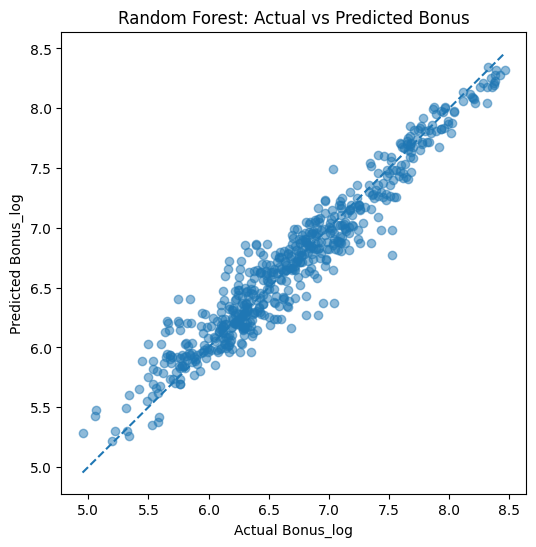

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test_b, preds_bonus_rf, alpha=0.5)
plt.xlabel("Actual Bonus_log")
plt.ylabel("Predicted Bonus_log")
plt.title("Random Forest: Actual vs Predicted Bonus")
plt.plot([y_test_b.min(), y_test_b.max()], [y_test_b.min(), y_test_b.max()], linestyle='--')
plt.show()

The scatter plot of actual versus predicted log-transformed bonus values demonstrates a strong alignment along the diagonal reference line, indicating a high level of predictive accuracy achieved by the model. Most data points are closely clustered around the ideal line, suggesting that the predicted values are very similar to the actual values with minimal error. This tight distribution reflects the model’s ability to effectively capture the underlying patterns and relationships influencing bonus allocation. Although slight deviations are observed at lower bonus values, the overall spread remains small, confirming consistent performance across different ranges. Therefore, the model exhibits strong generalization capability and reliability in predicting employee bonuses.

Plot actual vs predicted for Gradient Boosting

In [58]:
from sklearn.ensemble import GradientBoostingRegressor

gb_bonus = GradientBoostingRegressor(random_state=42)
gb_bonus.fit(X_train_b, y_train_b)
preds_bonus_gb = gb_bonus.predict(X_test_b)

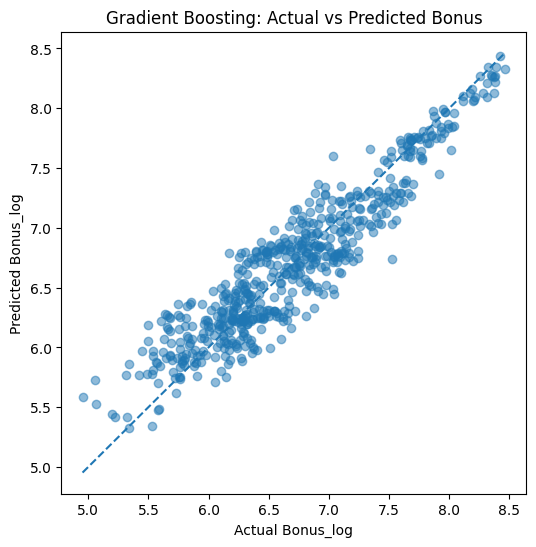

In [59]:
plt.figure(figsize=(6,6))
plt.scatter(y_test_b, preds_bonus_gb, alpha=0.5)
plt.xlabel("Actual Bonus_log")
plt.ylabel("Predicted Bonus_log")
plt.title("Gradient Boosting: Actual vs Predicted Bonus")
plt.plot([y_test_b.min(), y_test_b.max()], [y_test_b.min(), y_test_b.max()], linestyle='--')
plt.show()

The scatter plot of actual versus predicted log-transformed bonus values using the Gradient Boosting model shows a clear positive linear relationship, indicating that the model is able to capture the general trend in the data. Most points follow the diagonal reference line, which suggests that the predictions are reasonably close to the actual values. However, compared to the Random Forest model, a slightly wider spread of points around the diagonal can be observed, indicating higher prediction errors and less precision. This dispersion is more noticeable in the mid-range values, where the model exhibits greater variability. Despite this, the overall alignment confirms that Gradient Boosting still provides a strong predictive performance, although it is slightly less accurate and stable than the Random Forest model.

Feature importance for Random Forest bonus model

In [55]:
bonus_importance = pd.DataFrame({
    "Feature": X_bonus.columns,
    "Importance": rf_bonus.feature_importances_
}).sort_values(by="Importance", ascending=False)

display(bonus_importance.head(10))

,Feature,Importance
5,TotalWorkingYears,0.555195
4,PercentSalaryHike,0.106240
24,JobRole_Sales Executive,0.055102
19,JobRole_Laboratory Technician,0.038251
23,JobRole_Research Scientist,0.037652
22,JobRole_Research Director,0.035071
21,JobRole_Manufacturing Director,0.024061
11,Experience_Ratio,0.023760
3,MonthlyRate,0.017341
1,DailyRate,0.016446


Feature importance analysis using the Random Forest model revealed that Total Working Years is the most influential factor in predicting employee bonuses, contributing more than half of the model’s decision-making weight. This highlights the strong relationship between experience and bonus allocation. Percent Salary Hike was identified as the second most important feature, indicating that performance-based increases play a significant role in determining bonuses. Additionally, several job role categories, such as Sales Executive and Research-related positions, contributed to the prediction, suggesting that bonuses vary across different roles. Other features, including experience ratio and compensation rates, showed relatively lower importance. Overall, the results indicate that bonus prediction is primarily driven by experience, performance, and job position.

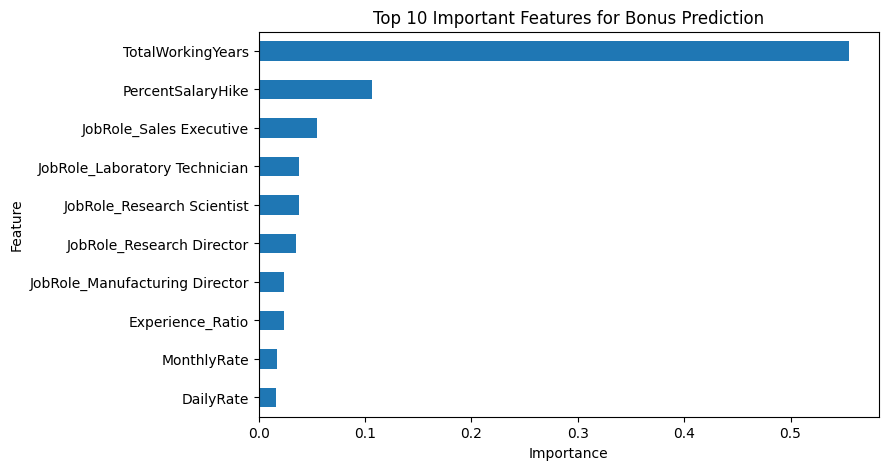

In [56]:
import matplotlib.pyplot as plt

bonus_importance.head(10).sort_values(by="Importance").plot(
    kind='barh', x='Feature', y='Importance', figsize=(8,5), legend=False
)

plt.title("Top 10 Important Features for Bonus Prediction")
plt.xlabel("Importance")
plt.show()

Cross Validation

In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(best_model, X_salary, y_salary, cv=5, scoring='r2')

print("Cross-validation R2 scores:", cv_scores)
print("Average R2:", cv_scores.mean())

Cross-validation R2 scores: [0.96017386 0.96399895 0.9606925  0.96165948 0.95638957]
Average R2: 0.960582872140266


Cross-validation was performed to evaluate the robustness of the model. The results showed consistently high R² scores across all folds, indicating that the model generalizes well to unseen data and maintains stable performance across different data splits.

Save the model

In [ ]:
import joblib

joblib.dump(best_model, "salary_model.pkl")
joblib.dump(rf_bonus, "bonus_model.pkl")

['bonus_model.pkl']

The final trained models were saved using joblib for future deployment. These models can be integrated into HR systems or web applications to provide real-time salary and bonus predictions for employees.